# Эксперимент 16: Lovász loss + AMP (batch×2) + Layer-wise LR decay

База — Эксп.10 (4 блока разморозки, синтетика кл.1+2, mIoU=0.5946). Три независимых улучшения:

| Изменение | Суть | Ожидаемый эффект |
|---|---|---|
| **Lovász loss** | Заменяет Dice, напрямую оптимизирует IoU | +2–5% mIoU |
| **AMP (fp16)** | Половина VRAM → batch 2→4, стабильнее BN | +1–3% mIoU |
| **Layer-wise LR** | Блок 11: 1e-5, блок 10: 7.5e-6, ..., блок 8: 4.2e-6 | +1–3% mIoU |

| | Эксп.10 | **Эксп.16** |
|---|---|---|
| Backbone | Разморожен (4 блока, единый LR 1e-5) | **Разморожен (4 блока, layer-wise LR)** |
| Loss | CE + 0.5×Dice | **CE + Lovász** |
| Batch size | 2 | **4 (AMP fp16)** |
| Синтетика | Да (кл.1+2) | **Да (кл.1+2)** |

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

INTERMEDIATE_LAYERS = [3, 5, 8, 11]

N_UNFREEZE   = 4        # блоки 8-11, как в Эксп.10
LR_BACKBONE  = 1e-5    # базовый LR для верхнего блока (11)
LR_DECAY     = 0.75    # множитель LR на каждый блок вниз
LR_HEAD      = 1e-3
BATCH_SIZE   = 4       # было 2 → удваиваем за счёт AMP
EPOCHS       = 75
N_SELECT     = 200
TEST_SIZE    = 0.2
SYNTH_WEIGHT = 0.5

FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3

USE_AMP = (DEVICE == 'cuda')

print(f'\nВход:              {IMG_H}x{IMG_W}')
print(f'Слои DPT:          {INTERMEDIATE_LAYERS}')
print(f'Разморожено блоков: {N_UNFREEZE} (блоки {12-N_UNFREEZE}-11)')
print(f'LR backbone base:  {LR_BACKBONE}  decay={LR_DECAY}')
print(f'  Блок 11: {LR_BACKBONE:.1e}')
print(f'  Блок 10: {LR_BACKBONE*LR_DECAY:.2e}')
print(f'  Блок  9: {LR_BACKBONE*LR_DECAY**2:.2e}')
print(f'  Блок  8: {LR_BACKBONE*LR_DECAY**3:.2e}')
print(f'Batch size:        {BATCH_SIZE}  (AMP={USE_AMP})')
print(f'Synth loss weight: {SYNTH_WEIGHT}')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:              224x1400
Слои DPT:          [3, 5, 8, 11]
Разморожено блоков: 4 (блоки 8-11)
LR backbone base:  1e-05  decay=0.75
  Блок 11: 1.0e-05
  Блок 10: 7.50e-06
  Блок  9: 5.63e-06
  Блок  8: 4.22e-06
Batch size:        4  (AMP=True)
Synth loss weight: 0.5


## 2. Данные и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Функции определены.')

Строк: 7,095  |  Изображений: 6,666
Функции определены.


## 3. Dataset (с поддержкой синтетики)

In [3]:
class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h        = img_h
        self.img_w        = img_w
        self.is_train     = is_train
        self.flip_p       = flip_p
        self.crop_scale   = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor    = transforms.ToTensor()
        self.normalize    = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir
        self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids
        self.img_dir  = img_dir
        self.df       = df
        self.jt       = joint_transform
        self.synth    = synth_pairs
        self.n_real   = len(real_ids)
        self.n_synth  = len(synth_pairs)
    def __len__(self):
        return self.n_real + self.n_synth
    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


print(f'Datasets определены. Маска: {MASK_H}x{MASK_W}')

Datasets определены. Маска: 64x400


## 4. Загрузка DINOv2 — разморозка блоков 8–11 (как Эксп.10)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)       # 12
unfreeze_from = n_blocks - N_UNFREEZE    # 8

for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True

for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0-{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}-{n_blocks-1} + norm)')

with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats)
    print(f'Forward check: OK  ({len(feats)} слоёв x {feats[0].shape})')
del test_img, feats

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM свободно: {free/1e9:.1f} ГБ / {total/1e9:.1f} ГБ')

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  58.2М  (блоки 0-7)
  Разморожено: 28.4М  (блоки 8-11 + norm)
Forward check: OK  (4 слоёв x torch.Size([1, 1600, 768]))
VRAM свободно: 4.0 ГБ / 8.5 ГБ


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
if os.path.exists(emb_cache):
    print('Загружаем из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t): self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    dinov2.eval()
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

Загружаем из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор 200 изображений

In [6]:
def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, classes_cache,
                              n_per_class=50, n_total=N_SELECT):
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_id_to_idx[i] for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


label_map = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: int(sorted(x.dropna().astype(int).tolist())[0]) if len(x) > 0 else 0
).to_dict()
all_labels = [label_map.get(i, 0) for i in labeled_ids]

train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()

emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}
pool_mask     = [emb_id_to_idx[i] for i in train_ids]
pool_embeds   = embeddings[pool_mask]
selected_ids  = stratified_active_select(
    pool_embeds, train_ids, classes_cache, n_per_class=50, n_total=N_SELECT)
print(f'Итого: {len(selected_ids)}')

Train pool: 5,332  |  Test: 1,334
Отбор: 199 гарант. + 1 KMeans = 200
Итого: 200


## 7. Архитектура: SegHeadDPT + Lovász-Softmax loss

**Lovász-Softmax** (Berman et al., CVPR 2018) — дифференцируемый суррогат IoU.
Реализован с нуля, без внешних зависимостей.

Итоговый лосс: `CE(weighted) + Lovász` — Dice убран, его заменяет Lovász.

In [7]:
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


# ── Lovász-Softmax ────────────────────────────────────────────────────────────

def _lovász_grad(gt_sorted):
    """Градиент расширения Lovász для отсортированных ошибок."""
    n   = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union        = gts + (1.0 - gt_sorted).float().cumsum(0)
    jaccard      = 1.0 - intersection / union
    if n > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def _lovász_softmax_flat(probas, labels):
    """
    Lovász-Softmax на плоских тензорах.
    probas : [N, C] float32  — вероятности после softmax
    labels : [N]   long      — метки классов
    Итерирует только по классам, присутствующим в батче.
    """
    C = probas.size(1)
    losses = []
    for c in range(C):
        fg = (labels == c).float()
        if fg.sum() == 0:
            continue
        errors = (fg - probas[:, c]).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, _lovász_grad(fg_sorted)))
    if not losses:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()


class LovászSoftmax(nn.Module):
    """
    Multi-class Lovász-Softmax loss (Berman et al., CVPR 2018).
    Напрямую оптимизирует mean IoU.
    Внутри всегда работает в fp32 — безопасно внутри autocast.
    """
    def forward(self, logits, targets):
        B, C, H, W = logits.shape
        probas  = F.softmax(logits.float(), dim=1)       # fp32 для стабильности
        probas  = probas.permute(0, 2, 3, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return _lovász_softmax_flat(probas, targets)


_h = SegHeadDPT().to(DEVICE)
print(f'SegHeadDPT:     {sum(p.numel() for p in _h.parameters()):,} параметров')
del _h
print('LovászSoftmax:  реализован с нуля (без внешних зависимостей)')

SegHeadDPT:     2,845,381 параметров
LovászSoftmax:  реализован с нуля (без внешних зависимостей)


## 8. Синтетика (кэш из Эксп.10)

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs_v2.pkl')

if not os.path.exists(synth_cache):
    raise FileNotFoundError(
        f'Кэш синтетики не найден: {synth_cache}\n'
        'Сначала запустите Experiment10_SynthFineTune_v2.ipynb до ячейки 9.'
    )

print('Загружаем синтетику из кэша Эксп.10 (synth_pairs_v2.pkl)...')
with open(synth_cache, 'rb') as f:
    synth_pairs = pickle.load(f)
print(f'Загружено: {len(synth_pairs)} синтетических пар (классы 1 и 2)')
print(f'Итого: {N_SELECT} реальных + {len(synth_pairs)} синтетических '
      f'= {N_SELECT + len(synth_pairs)} изображений')

Загружаем синтетику из кэша Эксп.10 (synth_pairs_v2.pkl)...
Загружено: 433 синтетических пар (классы 1 и 2)
Итого: 200 реальных + 433 синтетических = 633 изображений


## 9. Layer-wise LR decay — группы параметров

Каждый блок backbone получает свой LR: `LR_BACKBONE × decay^depth`,  
где depth=0 у блока 11 (верхнего), depth=3 у блока 8 (нижнего).

In [9]:
def make_backbone_param_groups(model, base_lr=LR_BACKBONE, decay=LR_DECAY,
                                n_unfreeze=N_UNFREEZE, weight_decay=1e-2):
    """
    Создаёт список param_groups с layer-wise LR decay для DINOv2.
    Верхний блок (11) получает base_lr, каждый следующий ниже — base_lr * decay^depth.
    """
    nb = len(model.blocks)
    unfreeze_from = nb - n_unfreeze
    groups = []

    # norm — тот же LR что у верхнего блока
    norm_params = [p for p in model.norm.parameters() if p.requires_grad]
    if norm_params:
        groups.append({'params': norm_params, 'lr': base_lr,
                       'weight_decay': weight_decay, 'name': 'norm'})

    # блоки сверху вниз
    for i in range(nb - 1, unfreeze_from - 1, -1):
        block_params = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if not block_params:
            continue
        depth = nb - 1 - i          # 0 → блок 11, 1 → блок 10, ...
        lr_i  = base_lr * (decay ** depth)
        groups.append({'params': block_params, 'lr': lr_i,
                       'weight_decay': weight_decay, 'name': f'block_{i}'})

    return groups


# Превью групп
preview = make_backbone_param_groups(dinov2)
print('Layer-wise LR backbone:')
for g in preview:
    n_p = sum(p.numel() for p in g['params'])
    print(f'  {g["name"]:<10}  LR={g["lr"]:.2e}  params={n_p/1e6:.2f}М')
total_bb = sum(sum(p.numel() for p in g['params']) for g in preview)
print(f'  Итого backbone: {total_bb/1e6:.1f}М')
print(f'  + head:         ~2.8М')

Layer-wise LR backbone:
  norm        LR=1.00e-05  params=0.00М
  block_11    LR=1.00e-05  params=7.09М
  block_10    LR=7.50e-06  params=7.09М
  block_9     LR=5.63e-06  params=7.09М
  block_8     LR=4.22e-06  params=7.09М
  Итого backbone: 28.4М
  + head:         ~2.8М


## 10. Функция обучения (AMP + Lovász + layer-wise LR)

In [10]:
def train_finetune(train_ids, val_ids, df, synth_pairs=None,
                   n_epochs=EPOCHS, label='ft_exp16',
                   checkpoint_every=25):

    head = SegHeadDPT().to(DEVICE)

    # Layer-wise LR decay для backbone + обычный LR для головы
    bb_groups   = make_backbone_param_groups(dinov2)
    head_group  = [{'params': list(head.parameters()),
                    'lr': LR_HEAD, 'weight_decay': 1e-4, 'name': 'head'}]
    opt   = optim.AdamW(bb_groups + head_group)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # AMP scaler
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    cw   = compute_class_weights(train_ids, df)
    cce  = nn.CrossEntropyLoss(weight=cw, reduction='none')
    clov = LovászSoftmax()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)

    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    total_bb = sum(sum(p.numel() for p in g['params']) for g in bb_groups)
    total_hd = sum(p.numel() for p in head.parameters())
    print(f'Обучаемых параметров: backbone {total_bb/1e6:.1f}М + head {total_hd/1e3:.0f}К')
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    if synth_pairs:
        print(f'  реальных: {len(train_ids)}, синтетических: {len(synth_pairs)}')
    print(f'AMP: {USE_AMP}  |  Batch: {BATCH_SIZE}')

    for ep in range(1, n_epochs + 1):
        # Backbone: eval для замороженных, train для разморозных
        dinov2.eval()
        for i, block in enumerate(dinov2.blocks):
            if i >= (n_blocks - N_UNFREEZE):
                block.train()
        dinov2.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()

            if scaler is not None:
                with torch.amp.autocast('cuda'):
                    feats = dinov2.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    lg = head(feats)
                    pixel_loss = cce(lg, masks)          # [B, H, W]
                    w_batch = torch.where(
                        is_synth.bool().to(DEVICE)[:, None, None],
                        torch.full_like(pixel_loss, SYNTH_WEIGHT),
                        torch.ones_like(pixel_loss)
                    )
                    ce_loss  = (pixel_loss * w_batch).mean()
                    lov_loss = clov(lg, masks)           # fp32 внутри LovászSoftmax
                    loss = ce_loss + lov_loss

                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                lg = head(feats)
                pixel_loss = cce(lg, masks)
                w_batch = torch.where(
                    is_synth.bool().to(DEVICE)[:, None, None],
                    torch.full_like(pixel_loss, SYNTH_WEIGHT),
                    torch.ones_like(pixel_loss)
                )
                loss = (pixel_loss * w_batch).mean() + clov(lg, masks)
                loss.backward()
                opt.step()

            tl += loss.item()
        sched.step()

        # Валидация
        dinov2.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                with torch.amp.autocast('cuda') if USE_AMP else torch.no_grad():
                    feats = dinov2.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    preds = head(feats).argmax(1)
                iou.update(preds, masks)

        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl / len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in dinov2.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_ep{ep}.pt')
            torch.save({'epoch': ep, 'head_state': head.state_dict(),
                        'backbone_state': dinov2.state_dict(),
                        'history': hist, 'best_miou': best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    dinov2.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 11. Обучение

In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM занято:   {torch.cuda.memory_allocated()/1e9:.1f} Гб')
    print(f'VRAM свободно: {free/1e9:.1f} Гб  /  {total/1e9:.1f} Гб')

print('='*70)
print(f'ЭКСП.16: {N_SELECT} реал. + {len(synth_pairs)} синт. | '
      f'batch={BATCH_SIZE} | AMP={USE_AMP}')
print(f'  Loss: CE(weighted) + Lovász')
print(f'  LR:   layer-wise decay {LR_BACKBONE:.0e} → {LR_BACKBONE*LR_DECAY**3:.2e}')
print('='*70)

model_16, history_16 = train_finetune(
    selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs,
    label='ft_exp16'
)

VRAM занято:   0.4 Гб
VRAM свободно: 4.0 Гб  /  8.5 Гб
ЭКСП.16: 200 реал. + 433 синт. | batch=4 | AMP=True
  Loss: CE(weighted) + Lovász
  LR:   layer-wise decay 1e-05 → 4.22e-06
Веса классов:
  Фон: 0.100  (78,181,311 пикс.)
  Дефект 1: 1.991  (236,225 пикс.)
  Дефект 2: 2.428  (193,649 пикс.)
  Дефект 3: 0.257  (1,832,305 пикс.)
  Дефект 4: 0.318  (1,476,510 пикс.)
Обучаемых параметров: backbone 28.4М + head 2845К
Обучающих: 633  |  Валидационных: 1334
  реальных: 200, синтетических: 433
AMP: True  |  Batch: 4
[ft_exp16] Эп   1/75 | Loss:0.6180 | mIoU:0.3933 | cls0:0.948  cls1:0.072  cls2:0.019  cls3:0.393  cls4:0.535
[ft_exp16] Эп  10/75 | Loss:0.3352 | mIoU:0.5613 | cls0:0.964  cls1:0.342  cls2:0.346  cls3:0.559  cls4:0.595
[ft_exp16] Эп  20/75 | Loss:0.2647 | mIoU:0.5345 | cls0:0.969  cls1:0.352  cls2:0.138  cls3:0.562  cls4:0.652
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_ft_exp16_ep25.pt
[ft_exp16] Эп  30/75 | Loss:0.2332 | mIoU:0.5844 | cls0:0.970  cls1:0.36

## 12. Сравнение с предыдущими экспериментами

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.9  (4 блока, без синт.)            : mIoU = 0.5406
  Эксп.10 (4 блока, синт., базис)         : mIoU = 0.5946
  Эксп.12 (4 блока, +аугм.)               : mIoU = 0.5903
  Эксп.14 (6 блоков, синт.)               : mIoU = 0.5840
  Эксп.16 (Lovász+AMP+layer-LR)           : mIoU = 0.6028

  Прирост vs Эксп.10 (базис): +0.8%

  Класс           Эксп.9  (4   Эксп.10 (4   Эксп.12 (4   Эксп.14 (6       Эксп.16
  -------------------------------------------------------------------------------
  Фон                  0.9585       0.9679       0.9685       0.9691       0.9708
  Дефект 1             0.2938       0.3858       0.3751       0.3622       0.3774
  Дефект 2             0.3412       0.3949       0.3867       0.3796       0.3999
  Дефект 3             0.4914       0.5913       0.5883       0.5709       0.5970
  Дефект 4             0.6183       0.6330       0.6327       0.6384       0.6692


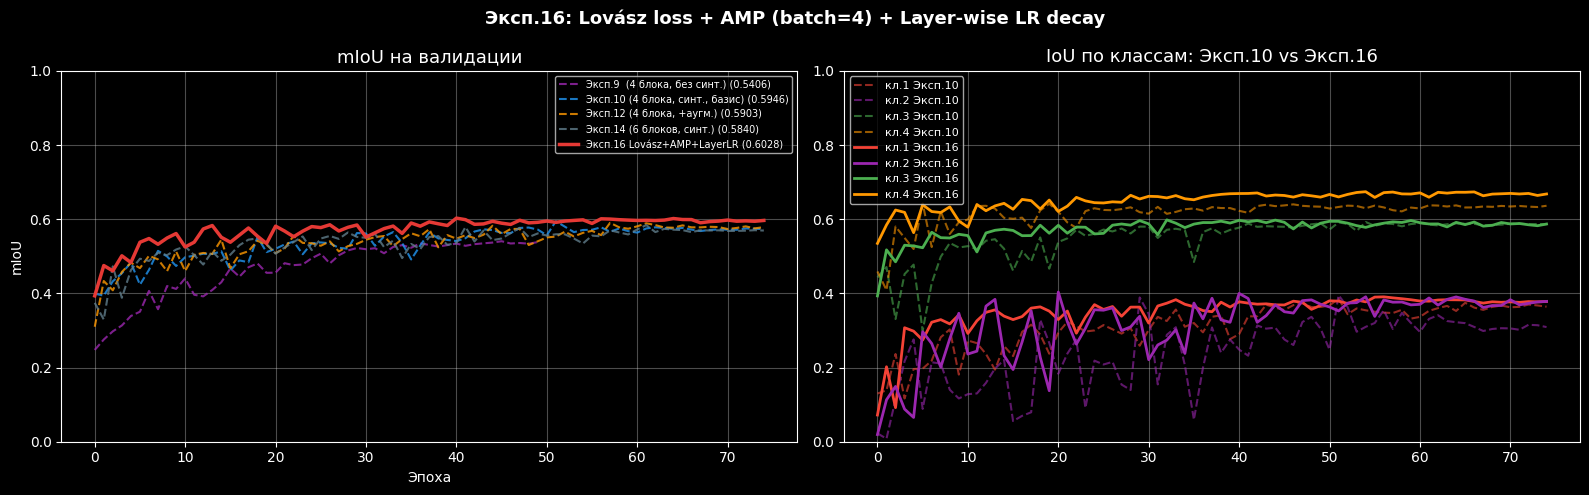

In [12]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

m_16 = max(history_16['val_miou'])
e_16 = int(np.argmax(history_16['val_miou']))
i_16 = history_16['val_iou_per_class'][e_16]

results = {}
for name, fname in [
    ('Эксп.9  (4 блока, без синт.)',    'history_ft_dpt_v2.json'),
    ('Эксп.10 (4 блока, синт., базис)', 'history_ft_dpt_synth_v2.json'),
    ('Эксп.12 (4 блока, +аугм.)',       'history_ft_dpt_aug.json'),
    ('Эксп.14 (6 блоков, синт.)',       'history_exp14_6blocks.json'),
]:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f:
            h = json.load(f)
        m = max(h['val_miou'])
        e = int(np.argmax(h['val_miou']))
        results[name] = {'miou': m, 'iou': h['val_iou_per_class'][e], 'hist': h}

print('ИТОГОВОЕ СРАВНЕНИЕ:')
for name, r in results.items():
    print(f'  {name:<40}: mIoU = {r["miou"]:.4f}')
print(f'  {"Эксп.16 (Lovász+AMP+layer-LR)":<40}: mIoU = {m_16:.4f}')

ref10 = results.get('Эксп.10 (4 блока, синт., базис)')
if ref10:
    print(f'\n  Прирост vs Эксп.10 (базис): {(m_16 - ref10["miou"])*100:+.1f}%')

print(f'\n  {"Класс":<14}', end='')
for name in results:
    print(f'{name[:11]:>13}', end='')
print(f'{"Эксп.16":>13}')
print('  ' + '-'*(14 + 13*len(results) + 13))
for c in range(NUM_CLASSES):
    print(f'  {names[c]:<14}', end='')
    for r in results.values():
        print(f'{r["iou"][c]:>13.4f}', end='')
    print(f'{i_16[c]:>13.4f}')

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = ['#9C27B0', '#2196F3', '#FF9800', '#607D8B']
for (name, r), col in zip(results.items(), palette):
    axes[0].plot(r['hist']['val_miou'], color=col, lw=1.5,
                 label=f'{name} ({r["miou"]:.4f})', ls='--', alpha=0.8)
axes[0].plot(history_16['val_miou'], color='#E53935', lw=2.5,
             label=f'Эксп.16 Lovász+AMP+LayerLR ({m_16:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

cls_colors = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
if ref10:
    for cls, col in cls_colors.items():
        axes[1].plot([h[cls] for h in ref10['hist']['val_iou_per_class']],
                     color=col, lw=1.5, ls='--', alpha=0.6, label=f'кл.{cls} Эксп.10')
for cls, col in cls_colors.items():
    axes[1].plot([h[cls] for h in history_16['val_iou_per_class']],
                 color=col, lw=2, label=f'кл.{cls} Эксп.16')
axes[1].set_title('IoU по классам: Эксп.10 vs Эксп.16', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)

plt.suptitle('Эксп.16: Lovász loss + AMP (batch=4) + Layer-wise LR decay',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Сохранение

In [13]:
torch.save(model_16.state_dict(),
           os.path.join(save_dir, 'model_exp16.pt'))
torch.save(dinov2.state_dict(),
           os.path.join(save_dir, 'dinov2_exp16.pt'))
with open(os.path.join(save_dir, 'history_exp16.json'), 'w') as f:
    json.dump(history_16, f)
print('Сохранено:')
print('  model_exp16.pt      — голова DPT')
print('  dinov2_exp16.pt     — backbone')
print('  history_exp16.json  — история обучения')
print(f'\nЛучший mIoU Эксп.16: {m_16:.4f}')
if ref10:
    print(f'Лучший mIoU Эксп.10: {ref10["miou"]:.4f}  (базис)')
    print(f'Прирост:             {(m_16 - ref10["miou"])*100:+.1f}%')

Сохранено:
  model_exp16.pt      — голова DPT
  dinov2_exp16.pt     — backbone
  history_exp16.json  — история обучения

Лучший mIoU Эксп.16: 0.6028
Лучший mIoU Эксп.10: 0.5946  (базис)
Прирост:             +0.8%
